#  Shopping Trends Analysis — Capstone Project
### Course: Foundations of Data Science
### Group Members:
1. Vansh Jain - 2502140093
2. Kapish Garg -2502140029
3. Bhavya -2502140019


## Step 1: Data Understanding


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re



df = pd.read_csv('shopping_trends_realistic.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns") 

Dataset loaded successfully!
Shape: 3960 rows × 20 columns


### Dataset Overview

In [2]:
df.head(10)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Order_Date
0,1,55,Male,Shorts,Clothing,83.92,Montana,S,Black,Fall,3.8,No,Credit Card,Standard,No,NO,26,Credit Card,Monthly,"September 01, 2022"
1,2,55,Female,Gloves,Accessories,85.60,Nebraska,L,Maroon,Fall,4.2,Yes,Venmo,Express,Yes,yes,43,Debit Card,Weekly,"April 24, 2022"
2,3,30,female,Sweater,Clothing,100.00,Wyoming,M,Maroon,Fall,2.9,No,Credit Card,Store Pickup,No,No,20,PayPal,Weekly,2023-12-25
3,4,42,Male,Coat,Outerwear,86.47,Louisiana,L,Silver,Winter,3.4,No,Venmo,Store Pickup,No,No,7,Credit Card,Weekly,11/11/2024
4,5,31,Male,Boots,Footwear,67.09,Kentucky,S,Pink,Summer,4.3,Yes,PayPal,Standard,Yes,Yes,35,Debit Card,Monthly,2022-03-19
5,6,22,Male,Gloves,Accessories,54.68,Nevada,M,Silver,Summer,4.2,Yes,Venmo,NEXT DAY AIR,No,No,42,PayPal,Weekly,"January 28, 2023"
6,7,36,Male,Sunglasses,Accessories,62.95,California,S,Green,Winter,3.0,No,Cash,Free Shipping,Yes,Yes,29,PayPal,Weekly,04/07/2023
7,8,62,Male,Coat,Outerwear,84.47,Georgia,S,Peach,Spring,3.3,No,Cash,Next Day Air,No,No,12,PayPal,Weekly,12/06/2023
8,9,37,Female,Sunglasses,Accessories,87.15,Colorado,M,Indigo,Fall,4.1,No,CreditCard,Free Shipping,No,No,23,Debit Card,Weekly,"December 08, 2023"
9,10,23,Female,T-shirt,Clothing,36.37,Indiana,S,Violet,Winter,2.9,No,Credit-Card,Free Shipping,Yes,Yes,11,Credit Card,Quarterly,"October 08, 2023"


### Column Names and Data Types

In [3]:
print("Column Names and Data Types:")

print(df.dtypes)

Column Names and Data Types:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)       float64
Location                     object
Size                         object
Color                        object
Season                       object
Review Rating               float64
Subscription Status          object
Payment Method               object
Shipping Type                object
Discount Applied             object
Promo Code Used              object
Previous Purchases            int64
Preferred Payment Method     object
Frequency of Purchases       object
Order_Date                   object
dtype: object


In [4]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases', 'Order_Date'],
      dtype='object')

### Dataset Shape and Basic Statistics


In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3960.000000,3960.000000,3901.000000,3901.000000,3960.000000
mean,1980.500000,37.743434,73.136665,3.864496,19.730303
std,1143.297861,12.038829,17.346048,0.592187,11.676276
min,1.000000,18.000000,20.000000,1.900000,1.000000
25%,990.750000,29.000000,61.070000,3.500000,11.000000
50%,1980.500000,37.000000,73.670000,3.900000,19.000000
75%,2970.250000,46.000000,86.220000,4.300000,27.000000
max,3960.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3960 non-null   int64  
 1   Age                       3960 non-null   int64  
 2   Gender                    3960 non-null   object 
 3   Item Purchased            3960 non-null   object 
 4   Category                  3901 non-null   object 
 5   Purchase Amount (USD)     3901 non-null   float64
 6   Location                  3960 non-null   object 
 7   Size                      3960 non-null   object 
 8   Color                     3960 non-null   object 
 9   Season                    3960 non-null   object 
 10  Review Rating             3901 non-null   float64
 11  Subscription Status       3960 non-null   object 
 12  Payment Method            3901 non-null   object 
 13  Shipping Type             3960 non-null   object 
 14  Discount

### Checking for Missing Values

In [7]:
missing = df.isnull().sum() 
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})

print(missing_df[missing_df['Missing Values'] > 0])

                       Missing Values  Percentage (%)
Category                           59            1.49
Purchase Amount (USD)              59            1.49
Review Rating                      59            1.49
Payment Method                     59            1.49


### Spotting Dirty Categorical Data

In [8]:
print("Unique values in 'Gender':", df['Gender'].unique().tolist())
print()
print("Unique values in 'Subscription Status':", df['Subscription Status'].unique().tolist())
print()
print("Unique values in 'Discount Applied':", df['Discount Applied'].unique().tolist())
print()
print("Unique values in 'Shipping Type':", df['Shipping Type'].unique().tolist())

Unique values in 'Gender': ['Male', 'Female', 'female', 'male', ' female', 'MALE', 'FEMALE', 'M', 'F', 'Male ']

Unique values in 'Subscription Status': ['No', 'Yes', 'NO', 'Y', 'yes', 'no', 'N', 'YES']

Unique values in 'Discount Applied': ['No', 'Yes', 'N', 'Y', 'YES', 'no', 'yes', 'NO']

Unique values in 'Shipping Type': ['Standard', 'Express', 'Store Pickup', 'NEXT DAY AIR', 'Free Shipping', 'Next Day Air', '2-Day Shipping', 'Free-Shipping', 'STANDARD', 'FREE SHIPPING', '2 Day Shipping', '2DAY SHIPPING', 'express', '2-day shipping', 'next day air', 'EXPRESS', 'free shipping', 'Standard ', ' Express', 'Next-Day-Air', 'STORE PICKUP', 'store pickup', 'standard', 'Store-Pickup']


### Spotting Dirty Item Names

In [9]:
dirty_items = [x for x in df['Item Purchased'].unique() if re.search(r'[^a-zA-Z0-9\s]', str(x))]
print(f"Items with special characters ({len(dirty_items)} found):")
print(dirty_items)

Items with special characters (150 found):
['T-shirt', 'Boots@!', 'Blouse@!', 'Belt##!', 'Jacket@#', 'Coat##!', 'Coat##', 'Handbag@@@', 'Sunglasses@!', 'Boots!!!', 'Jeans@@@', 'Jacket@@@', 'Jewelry##!', 'Handbag##', 'Belt@!', 'Skirt##!', 'Sneakers@!', 'Pants@#', 'Hat@@@', 'Hat##', 'Jewelry@@@', 'Jacket@!', 'Jeans@#', 'Sunglasses!!', 'Shoes@@@', 'T-shirt  ', 'Dress@@@', 'Jacket!!', 'Gloves##', 'Jewelry@!', 'Pants##!', 'Coat!!', 'Backpack!!', 'Skirt@!', 'Sneakers!!', 'Pants@@@', 'Gloves@!', 'Shirt@!', 'Shoes@!', 'Boots!!', 'Pants!!!', 'Blouse@#', 'Blouse@@@', 'Jeans@!', 'Coat@#', 'Sneakers##', 'T-shirt##', 'Handbag!!', 'Jewelry!!!', 'Sneakers##!', 'Boots@@@', 'Scarf##', 'Jeans##', 'Belt!!!', 'Coat@@@', 'Dress@#', 'Shoes!!!', 'Shorts@@@', 'Dress##!', 'Scarf@#', 'Sandals@!', 'Shirt!!!', 'Backpack##!', 'Hoodie@!', 'T-shirt@!', 'Skirt##', 'Dress@!', 'Dress!!!', 'Scarf!!!', 'Jacket##', 'Gloves!!!', 'Sweater!!!', 'Sandals##!', 'Sunglasses@@@', 'Hat##!', 'Sandals@#', 'Sunglasses##!', 'T-shirt!!

## Step 2: Data Wrangling

###  Dropping Missing Values

In [10]:
rows_before = len(df)
df = df.dropna()
rows_after = len(df)

print(f"Rows before dropping nulls : {rows_before}")
print(f"Rows after dropping nulls  : {rows_after}")
print(f"Rows removed               : {rows_before - rows_after}")
print(f"Missing values remaining   : {df.isnull().sum().sum()}")

Rows before dropping nulls : 3960
Rows after dropping nulls  : 3901
Rows removed               : 59
Missing values remaining   : 0


### Standardizing Gender Column

In [11]:
def standardize_gender(val):
    val = str(val).strip().lower()
    if val in ['male', 'm']:
        return 'Male'
    elif val in ['female', 'f']:
        return 'Female'
    return val

df['Gender'] = df['Gender'].apply(standardize_gender)
print("Gender values after cleaning:", df['Gender'].unique().tolist())
print(df['Gender'].value_counts())

Gender values after cleaning: ['Male', 'Female']
Gender
Male      2513
Female    1388
Name: count, dtype: int64


###  Standardizing Yes/No Columns

In [12]:
def standardize_yesno(val):
    val = str(val).strip().lower()
    if val in ['yes', 'y']:
        return 'Yes'
    elif val in ['no', 'n']:
        return 'No'
    return val

for col in ['Subscription Status', 'Discount Applied', 'Promo Code Used']:
    df[col] = df[col].apply(standardize_yesno)
    print(f"{col}: {df[col].unique().tolist()}")

Subscription Status: ['No', 'Yes']
Discount Applied: ['No', 'Yes']
Promo Code Used: ['No', 'Yes']


### Standardizing Shipping Type

In [13]:
def standardize_shipping(val):
    val = str(val).strip().lower().replace('-', ' ').replace('_', ' ')
    val = ' '.join(val.split())  # collapse multiple spaces
    mapping = {
        'standard': 'Standard',
        'express': 'Express',
        'free shipping': 'Free Shipping',
        'next day air': 'Next Day Air',
        'store pickup': 'Store Pickup',
        '2 day shipping': '2-Day Shipping',
        '2day shipping': '2-Day Shipping',
    }
    return mapping.get(val, val.title())

df['Shipping Type'] = df['Shipping Type'].apply(standardize_shipping)
print("Shipping Types after cleaning:")
print(df['Shipping Type'].value_counts())

Shipping Types after cleaning:
Shipping Type
Free Shipping     1111
Standard           823
Express            597
2-Day Shipping     565
Next Day Air       494
Store Pickup       311
Name: count, dtype: int64


### Standardizing Payment Method Columns

In [14]:
def standardize_payment(val):
    val = str(val).strip().lower().replace('-', ' ').replace('_', ' ')
    val = ' '.join(val.split())
    mapping = {
        'credit card': 'Credit Card',
        'creditcard': 'Credit Card',
        'debit card': 'Debit Card',
        'debitcard': 'Debit Card',
        'paypal': 'PayPal',
        'pay pal': 'PayPal',
        'venmo': 'Venmo',
        'cash': 'Cash',
        'bank transfer': 'Bank Transfer',
        'banktransfer': 'Bank Transfer',
    }
    return mapping.get(val, val.title())

df['Payment Method'] = df['Payment Method'].apply(standardize_payment)
df['Preferred Payment Method'] = df['Preferred Payment Method'].apply(standardize_payment)

print("Payment Method unique values:", df['Payment Method'].unique().tolist())
print("Preferred Payment unique values:", df['Preferred Payment Method'].unique().tolist())

Payment Method unique values: ['Credit Card', 'Venmo', 'PayPal', 'Cash', 'Debit Card', 'Bank Transfer']
Preferred Payment unique values: ['Credit Card', 'Debit Card', 'PayPal', 'Cash', 'Venmo', 'Bank Transfer']


### Cleaning Item Names (Removing Special Characters)

In [15]:
df['Item Purchased'] = df['Item Purchased'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x)).strip())

print(f"Unique items after cleaning: {df['Item Purchased'].nunique()}")
print("Sample items:", df['Item Purchased'].unique()[:15].tolist())

Unique items after cleaning: 24
Sample items: ['Shorts', 'Gloves', 'Sweater', 'Coat', 'Boots', 'Sunglasses', 'Tshirt', 'Backpack', 'Dress', 'Hoodie', 'Jeans', 'Scarf', 'Sneakers', 'Blouse', 'Belt']


### Parsing and Standardizing the Order Date

In [16]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'],errors='coerce')

date_nulls = df['Order_Date'].isnull().sum()
print(f"Dates that couldn't be parsed: {date_nulls}")


df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

print(f"\nDate range: {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}")
print(f"\nYear distribution:")
print(df['Year'].value_counts().sort_index())

Dates that couldn't be parsed: 2604

Date range: 2022-01-02 → 2024-12-28

Year distribution:
Year
2022.0    437
2023.0    430
2024.0    430
Name: count, dtype: int64


### Creating New Derived Columns

In [17]:

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[17, 24, 34, 44, 54, 70],
    labels=['18–24', '25–34', '35–44', '45–54', '55–70']
)


df['Spending_Tier'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 50, 75, 100],
    labels=['Low (<$50)', 'Medium ($50–$75)', 'High (>$75)']
)


df['Used_Any_Discount'] = ((df['Discount Applied'] == 'Yes') | (df['Promo Code Used'] == 'Yes')).map({True: 'Yes', False: 'No'})

print("Age Group distribution:")
print(df['Age_Group'].value_counts().sort_index())
print("\nSpending Tier distribution:")
print(df['Spending_Tier'].value_counts())
print("\nUsed Any Discount:")
print(df['Used_Any_Discount'].value_counts())

Age Group distribution:
Age_Group
18–24     613
25–34     997
35–44    1163
45–54     766
55–70     362
Name: count, dtype: int64

Spending Tier distribution:
Spending_Tier
High (>$75)         1842
Medium ($50–$75)    1662
Low (<$50)           397
Name: count, dtype: int64

Used Any Discount:
Used_Any_Discount
Yes    1983
No     1918
Name: count, dtype: int64


### Final Cleaned Dataset Overview

In [18]:
print(f"Final dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
df.head()

Final dataset shape: (3901, 26)
Missing values: 10416



,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases,Preferred Payment Method,Frequency of Purchases,Order_Date,Year,Month,Month_Name,Age_Group,Spending_Tier,Used_Any_Discount
0,1,55,Male,Shorts,Clothing,83.92,Montana,S,Black,Fall,...,26,Credit Card,Monthly,2022-09-01,2022.0,9.0,Sep,55–70,High (>$75),No
1,2,55,Female,Gloves,Accessories,85.60,Nebraska,L,Maroon,Fall,...,43,Debit Card,Weekly,2022-04-24,2022.0,4.0,Apr,55–70,High (>$75),Yes
2,3,30,Female,Sweater,Clothing,100.00,Wyoming,M,Maroon,Fall,...,20,PayPal,Weekly,NaT,NaN,NaN,NaN,25–34,High (>$75),No
3,4,42,Male,Coat,Outerwear,86.47,Louisiana,L,Silver,Winter,...,7,Credit Card,Weekly,NaT,NaN,NaN,NaN,35–44,High (>$75),No
4,5,31,Male,Boots,Footwear,67.09,Kentucky,S,Pink,Summer,...,35,Debit Card,Monthly,NaT,NaN,NaN,NaN,25–34,Medium ($50–$75),Yes


## Step 3: Data Visualization

### Distribution of Purchase Amounts (Histogram)

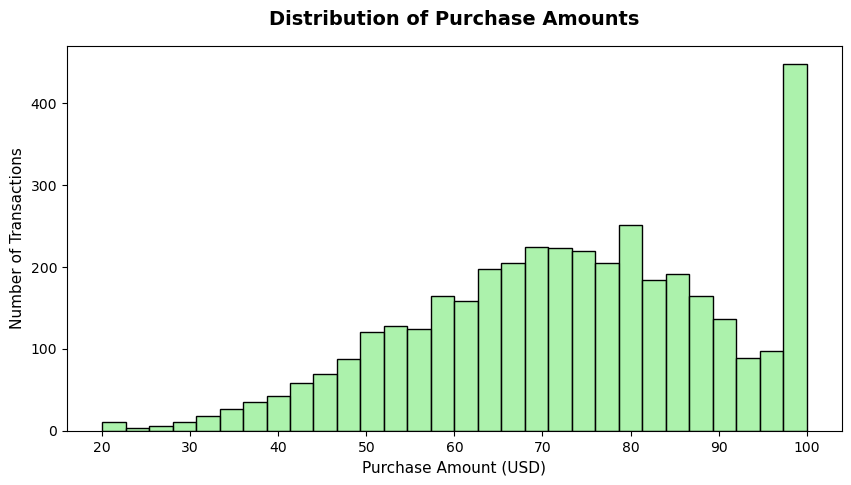

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Purchase Amount (USD)',
    bins=30,
    color='lightgreen'
)

ax.set_title('Distribution of Purchase Amounts', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Purchase Amount (USD)', fontsize=11)
ax.set_ylabel('Number of Transactions', fontsize=11)
plt.show()

###  Sales by Product Category (Bar Plot)

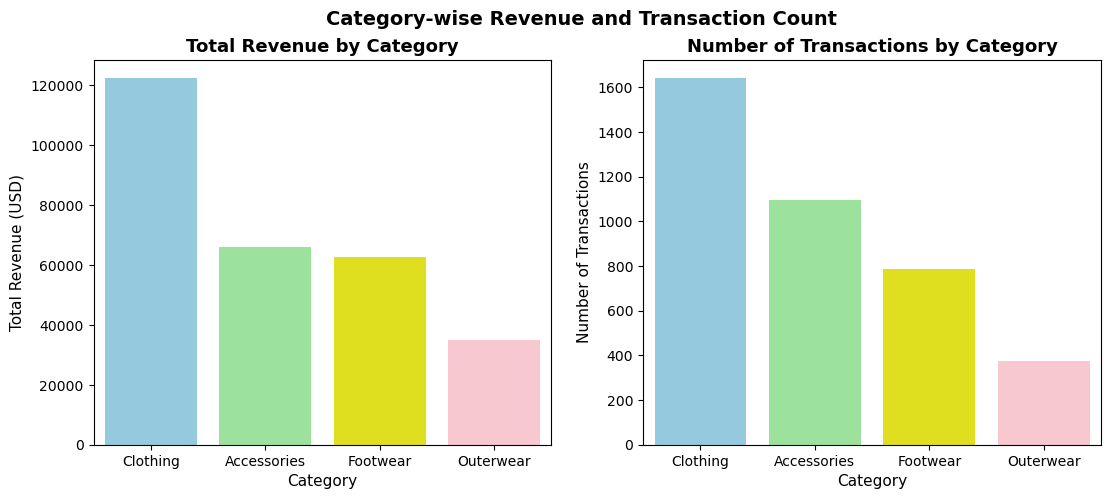

In [20]:
cat_revenue = df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False).reset_index()
cat_count = df['Category'].value_counts().reset_index()
cat_count.columns = ['Category', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = ['skyblue', 'lightgreen', 'yellow', 'pink']

sns.barplot(data=cat_revenue, x='Category', y='Purchase Amount (USD)',hue='Category', palette=palette, ax=axes[0])
axes[0].set_title('Total Revenue by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category', fontsize=11)
axes[0].set_ylabel('Total Revenue (USD)', fontsize=11)

sns.barplot(data=cat_count, x='Category', y='Count',hue='Category', palette=palette, ax=axes[1])
axes[1].set_title('Number of Transactions by Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Category', fontsize=11)
axes[1].set_ylabel('Number of Transactions', fontsize=11)


plt.suptitle('Category-wise Revenue and Transaction Count', fontsize=14, fontweight='bold')
plt.show()

### Gender Distribution of Shoppers (Pie Chart)

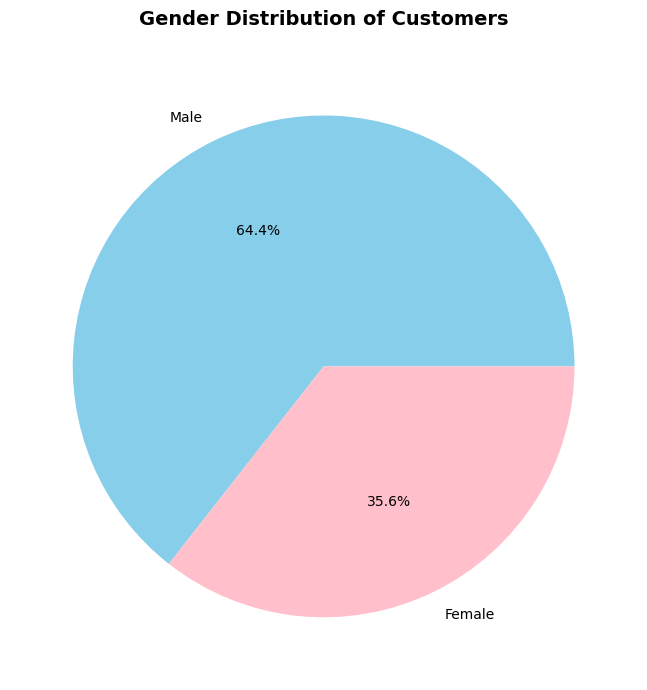

Gender
Male      2513
Female    1388
Name: count, dtype: int64


In [21]:
gender_counts = df['Gender'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

colors = ['skyblue', 'pink']
ax.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
)


ax.set_title('Gender Distribution of Customers', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(gender_counts)

### Seasonal Sales Breakdown (Pie Chart)

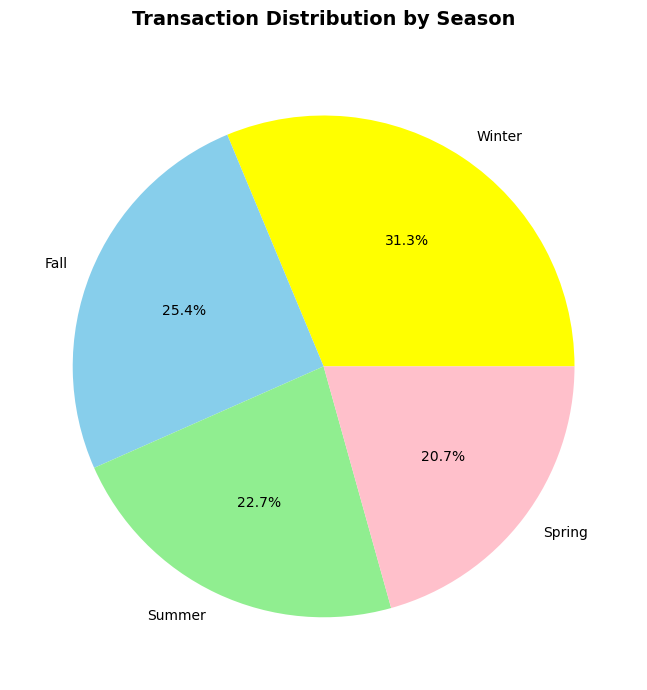

Season
Winter    1220
Fall       989
Summer     886
Spring     806
Name: count, dtype: int64


In [22]:
season_counts = df['Season'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))

season_colors = ['yellow', 'skyblue', 'lightgreen', 'pink']
ax.pie(
    season_counts,
    labels=season_counts.index,
    autopct='%1.1f%%',
    colors=season_colors,
)

ax.set_title('Transaction Distribution by Season', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(season_counts)

### Age vs. Purchase Amount (Scatter Plot)

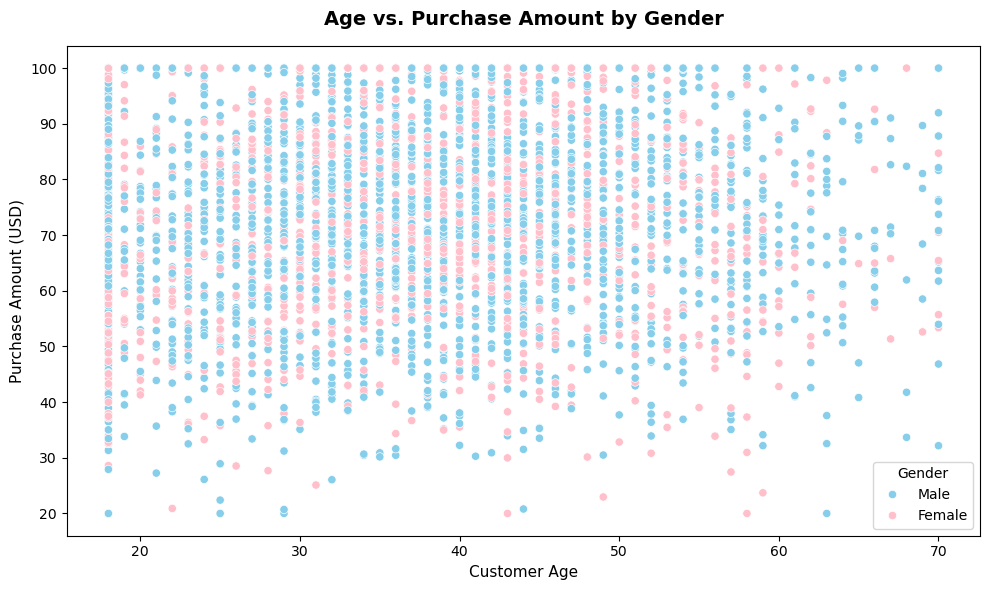

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Purchase Amount (USD)',
    hue='Gender',
    palette={'Male': 'skyblue', 'Female': 'pink'},
    ax=ax
)

ax.set_title('Age vs. Purchase Amount by Gender', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Age', fontsize=11)
ax.set_ylabel('Purchase Amount (USD)', fontsize=11)
ax.legend(title='Gender', fontsize=10)
plt.tight_layout()
plt.show()

###  Average Spending by Age Group (Bar Plot)

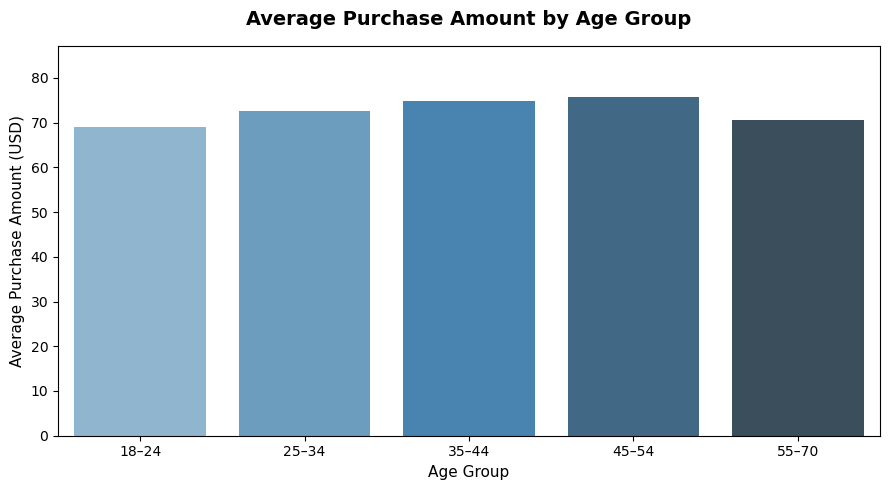

In [24]:
age_spend = df.groupby('Age_Group', observed=True)['Purchase Amount (USD)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=age_spend,
    x='Age_Group',
    y='Purchase Amount (USD)',
    hue='Age_Group', 
    palette='Blues_d',
    ax=ax
)


ax.set_title('Average Purchase Amount by Age Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Average Purchase Amount (USD)', fontsize=11)
ax.set_ylim(0, age_spend['Purchase Amount (USD)'].max() * 1.15)
plt.tight_layout()
plt.show()

### Payment Method Preferences (Bar Plot)

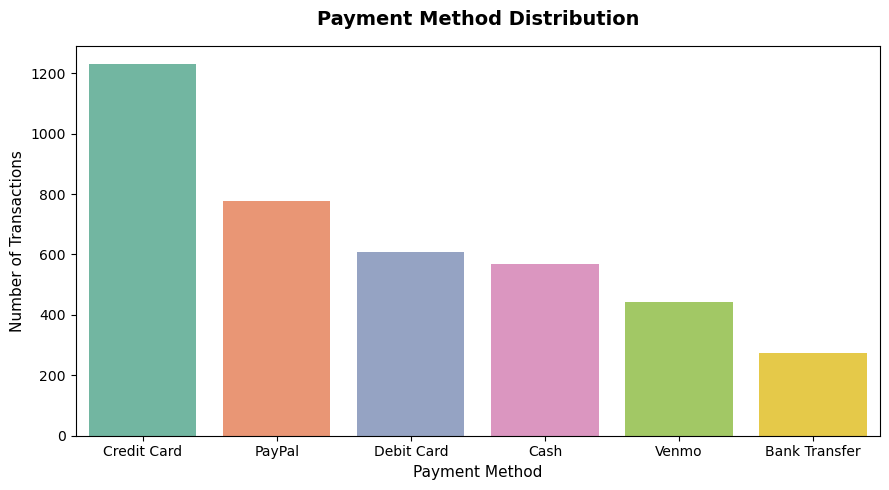

In [25]:
pay_counts = df['Payment Method'].value_counts().reset_index()
pay_counts.columns = ['Payment Method', 'Count']

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=pay_counts,
    x='Payment Method',
    y='Count',
    hue='Payment Method', 
    palette='Set2',
    ax=ax
)


ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Payment Method', fontsize=11)
ax.set_ylabel('Number of Transactions', fontsize=11)
plt.tight_layout()
plt.show()

### Review Rating Distribution by Category (Box Plot)

Are some product categories consistently rated higher than others? A box plot is perfect for this — it shows us the median, spread, and outliers for review ratings across all four categories at once.

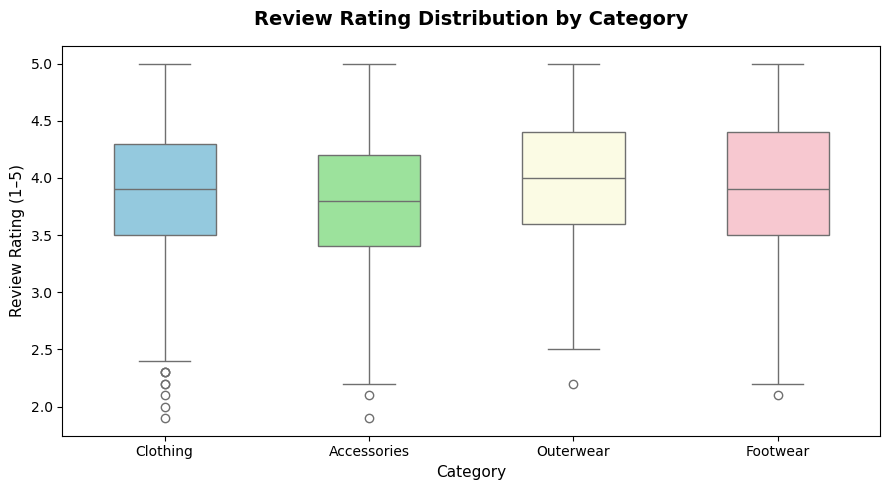

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Category',
    y='Review Rating',
    hue='Category',
    palette=['skyblue', 'lightgreen', 'lightyellow', 'pink'],
    width=0.5,
    ax=ax
)

ax.set_title('Review Rating Distribution by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Review Rating (1–5)', fontsize=11)
plt.tight_layout()
plt.show()

### Impact of Discounts on Purchase Amount (Bar Plot)

Do discounts actually lead to higher spending, or do people just use them to get a lower price on what they'd already buy? Let's compare average spending between customers who used any discount/promo versus those who didn't.

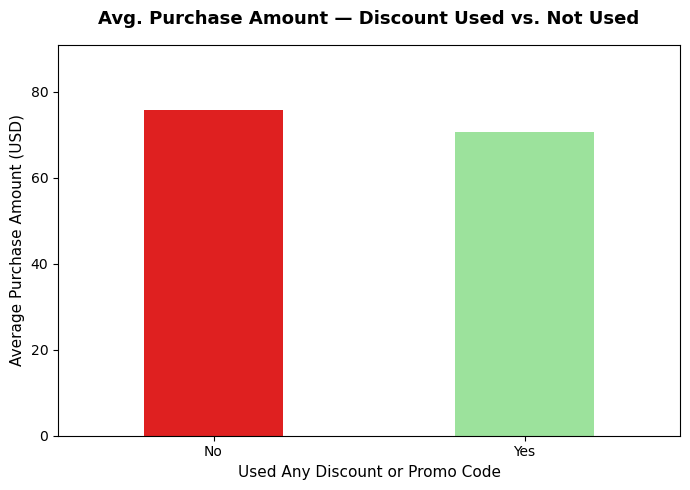

In [27]:
discount_spend = df.groupby('Used_Any_Discount')['Purchase Amount (USD)'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    data=discount_spend,
    x='Used_Any_Discount',
    y='Purchase Amount (USD)',
    hue='Used_Any_Discount',
    palette={'Yes': 'lightgreen', 'No': 'red'},
    width=0.45,
    ax=ax
)


ax.set_title('Avg. Purchase Amount — Discount Used vs. Not Used', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Used Any Discount or Promo Code', fontsize=11)
ax.set_ylabel('Average Purchase Amount (USD)', fontsize=11)
ax.set_ylim(0, discount_spend['Purchase Amount (USD)'].max() * 1.2)
plt.tight_layout()
plt.show()

### Top 10 Most Purchased Items (Bar Plot)

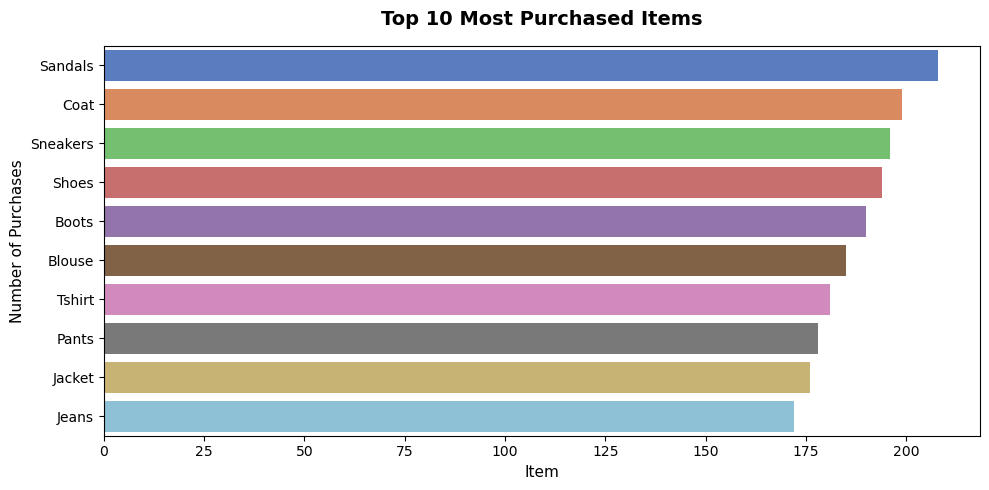

In [28]:
top_items = df['Item Purchased'].value_counts().head(10).reset_index()
top_items.columns = ['Item', 'Count']

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=top_items,
    x='Count',
    y='Item',
    hue='Item',
    palette='muted',
    ax=ax
)


ax.set_title('Top 10 Most Purchased Items', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Item', fontsize=11)
ax.set_ylabel('Number of Purchases', fontsize=11)
plt.tight_layout()
plt.show()

### KDE (Kernel Density Estimation) Analysis

### KDE 1 - Purchase Amount Distribution by Gender

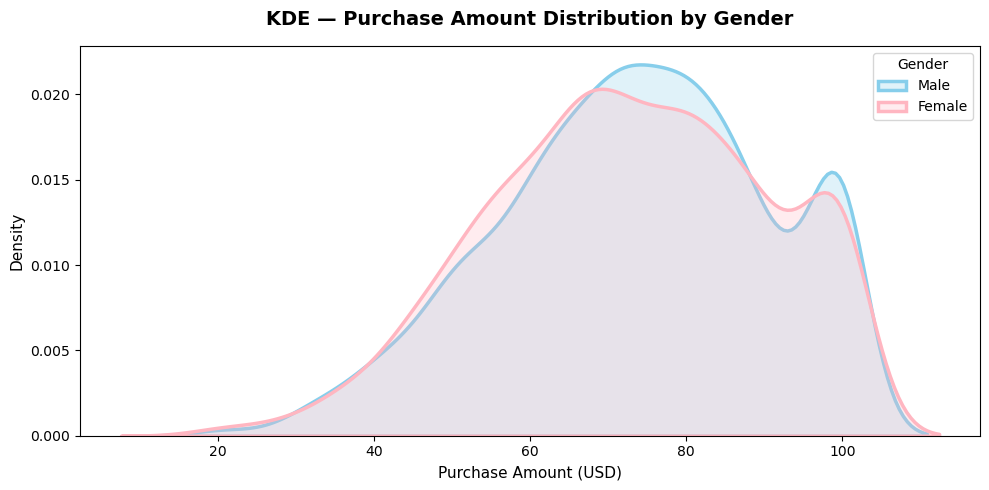

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

for gender, color in zip(['Male', 'Female'], ['skyblue', 'lightpink']):
    subset = df[df['Gender'] == gender]['Purchase Amount (USD)']
    sns.kdeplot(
        data=subset,
        label=gender,
        linewidth=2.5,
        color=color,
        fill=True,
        ax=ax
    )

ax.set_title('KDE — Purchase Amount Distribution by Gender', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Purchase Amount (USD)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(title='Gender', fontsize=10)
plt.tight_layout()
plt.show()


### KDE 2 - Age Distribution by Product Category

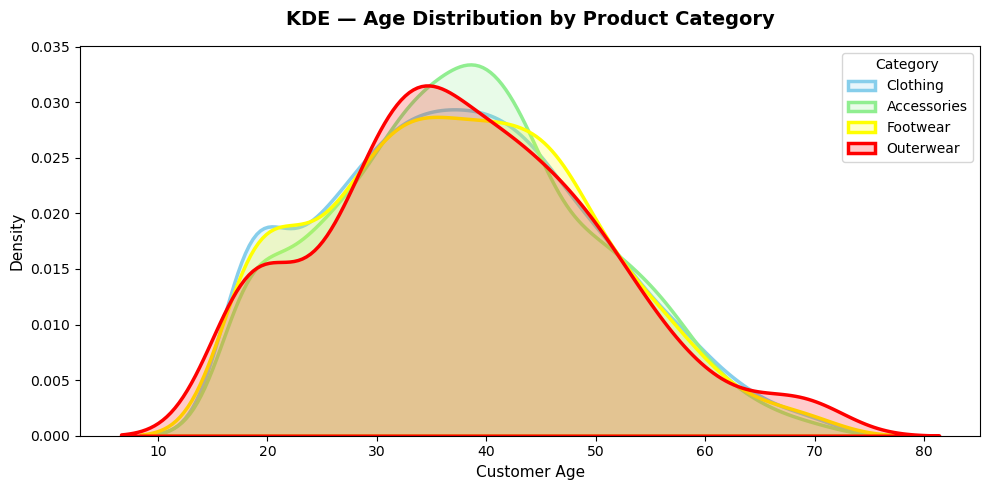

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

category_colors = {
    'Clothing':    'skyblue',
    'Accessories': 'lightgreen',
    'Footwear':    'yellow',
    'Outerwear':   'red'
}

for category, color in category_colors.items():
    subset = df[df['Category'] == category]['Age']
    sns.kdeplot(
        data=subset,
        label=category,
        color=color,
        linewidth=2.5,
        fill=True,
        alpha=0.2,
        ax=ax
    )

ax.set_title('KDE — Age Distribution by Product Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Customer Age', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(title='Category', fontsize=10)
plt.tight_layout()
plt.show()


### KDE 3 — Purchase Amount by Season

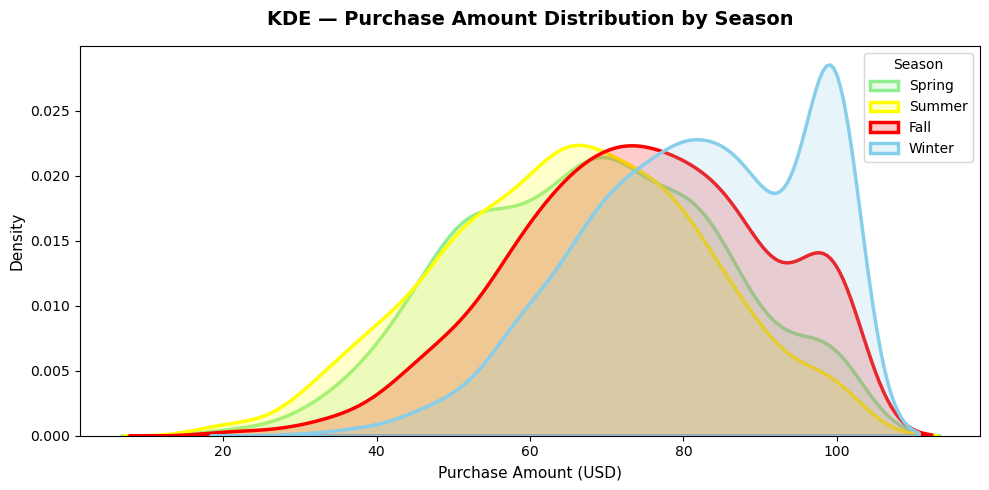

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

season_colors = {
    'Spring': 'lightgreen',
    'Summer': 'yellow',
    'Fall':   'red',
    'Winter': 'skyblue'
}

for season, color in season_colors.items():
    subset = df[df['Season'] == season]['Purchase Amount (USD)']
    sns.kdeplot(
        data=subset,
        label=season,
        color=color,
        linewidth=2.5,
        fill=True,
        alpha=0.2,
        ax=ax
    )

ax.set_title('KDE — Purchase Amount Distribution by Season', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Purchase Amount (USD)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(title='Season', fontsize=10)
plt.tight_layout()
plt.show()


###  Pairplot of Numeric Features


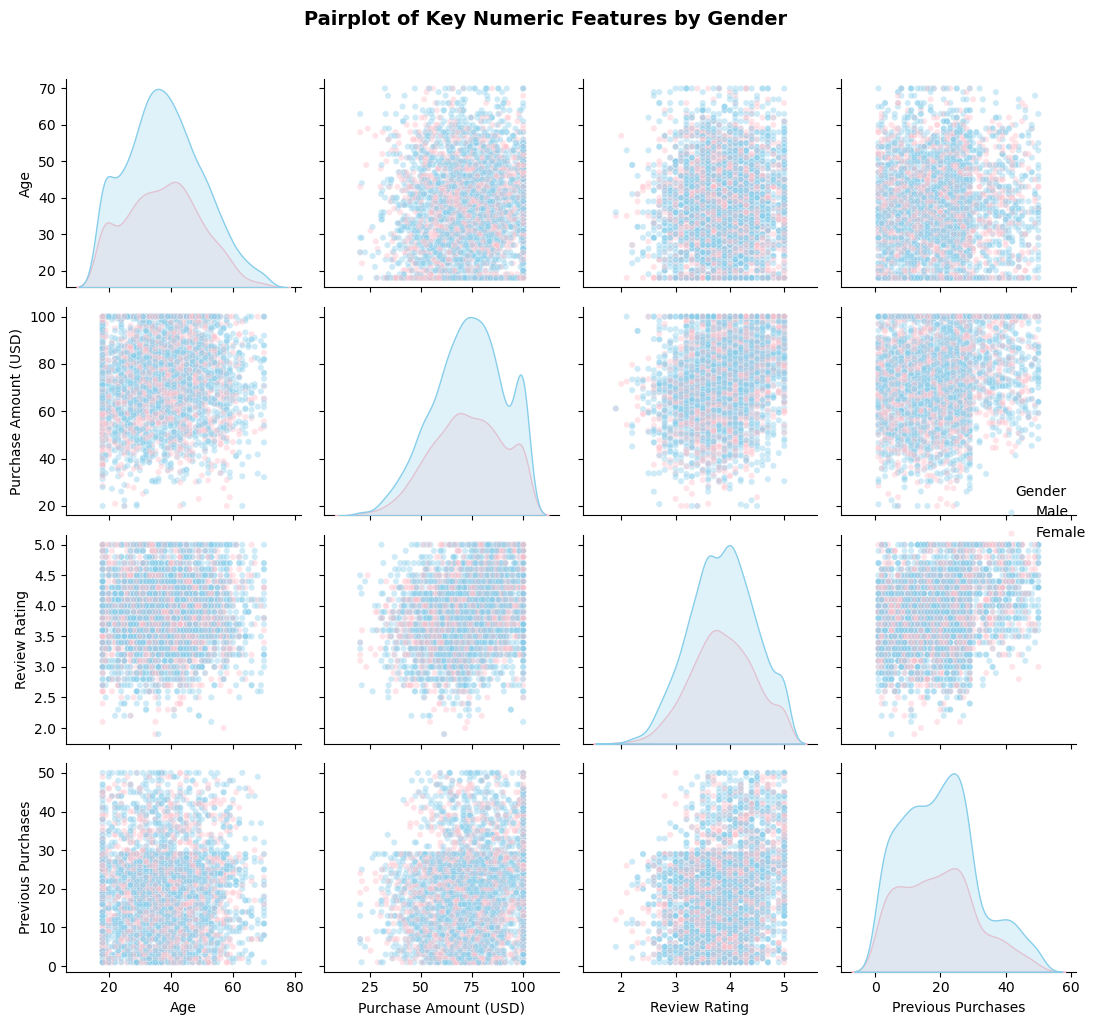

In [32]:
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

pairplot_df = df[numeric_cols + ['Gender']].copy()

pair_grid = sns.pairplot(
    pairplot_df,
    hue='Gender',
    palette={'Male': 'skyblue', 'Female': 'pink'},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 20},
    height=2.5
)

pair_grid.figure.suptitle('Pairplot of Key Numeric Features by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()